# Lab 03: Is There a Planet in Your Light Curve?

**ASTR 457, Fall 2026, posted Thu Sep 17, due Wed Sep 23 by Noon (fork → PR, as always)**

*Why this lab: transit fitting by maximum likelihood is how thousands of planets, including every temperate world around an M dwarf that David Charbonneau will talk about at the Sep 29 colloquium, were actually measured, and the gap between an error bar computed the lazy way and one computed honestly is exactly the gap between a claim that survives referees and one that doesn't.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `t_days`
(time from the start of a ~27-day TESS-style observing sector, 30-minute cadence, with a
~1-day data gap in the middle), `flux_rel` (relative flux, normalized near 1), and
`sigma_flux` (the per-point **white-noise** uncertainty). Your star is a nearby M dwarf
with a candidate transiting super-Earth. The light curve contains: the transit train,
slow instrumental systematics (drifts over days), and, as you will discover, noise
that is not entirely captured by `sigma_flux`. I know the true mid-transit time $t_0$,
period $P$, depth $\delta$, and duration $T$ for your dataset. You don't, you can't look
them up, and your classmates' planets are different from yours.

**How this is graded.** As always: on whether your answers are *right* and your
uncertainties are *honest*. Your reported depth and period are compared to your truth in
units of your own reported uncertainty. Anti-sandbagging cap: your $\sigma_\delta$ may
not exceed 3× a reference uncertainty I compute for your dataset; defensive error bars
lose points just like overconfident ones.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and
document it in Part 4. You may be selected to defend this lab in person (the practice
round was Sep 15; the real ones use the same format).

## The transit model (given)

Use this five-parameter periodic trapezoid, the small-planet limit of Mandel & Agol
(2002), the same model from Tuesday's lecture. The parameters are
$\theta = (t_0, P, \delta, T, F_0)$: mid-transit time of the first transit, period,
depth, total duration, and out-of-transit baseline flux. Ingress and egress each span
20% of the duration.

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def transit_model(t, t0, period, depth, duration, baseline, ingress_frac=0.2):
    """Periodic trapezoidal transit train."""
    ph = ((t - t0 + 0.5 * period) % period) - 0.5 * period
    half = duration / 2.
    ing = ingress_frac * duration
    f = np.ones_like(t)
    inside = np.abs(ph) < half
    full = np.abs(ph) < (half - ing)
    f[inside] = 1. - depth * np.clip((half - np.abs(ph[inside])) / ing, 0., 1.)
    f[full] = 1. - depth
    return baseline * f

NETID = 'saumyap2' # <-- set this
d = np.genfromtxt(f'../../labs/03/data/{NETID}.csv', delimiter=',', names=True, skip_header=1)
t, flux, sigma = d['t_days'], d['flux_rel'], d['sigma_flux']
print(f'{len(t)} points spanning {t[-1]:.1f} days; stated sigma = {sigma[0]*1e3:.2f} ppt')

1263 points spanning 27.4 days; stated sigma = 1.04 ppt


## Part 1: Find the planet (20%)

1. Plot the raw light curve. Identify the slow systematic trend and the transits.
2. **Detrend** the light curve. Be deliberate: state your method (median filter, spline,
   polynomial per segment, your choice), your smoothing scale, and *why that scale
   can't eat your transits*. Plot raw, trend, and detrended flux.
3. From the detrended curve, read off by eye: approximate $t_0$, $P$, depth, duration:
   your initial guesses for Part 2.
4. Compare the out-of-transit scatter of your detrended flux to the stated `sigma_flux`.
   Are they consistent? Say what you conclude (a sentence is fine, and you'll need this
   observation in Parts 2 and 3).

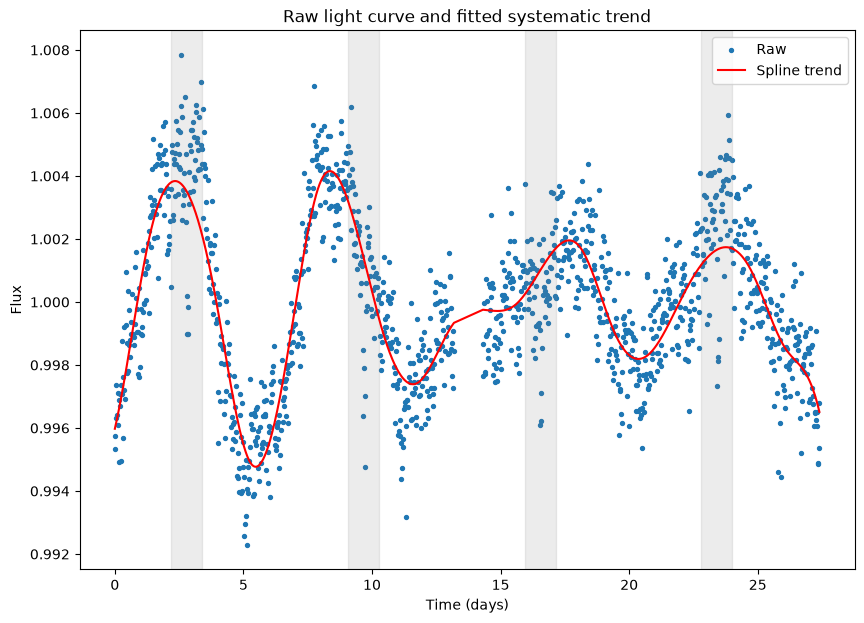

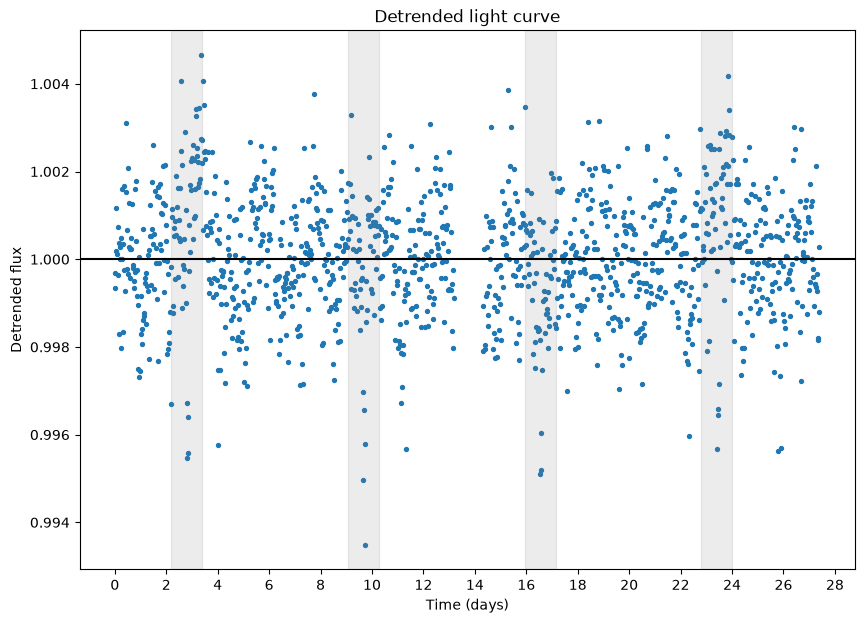

Out-of-transit scatter = 0.001277
Stated sigma_flux      = 0.001042
Ratio                  = 1.23


In [74]:
# Part 1: your work here
from scipy.interpolate import UnivariateSpline

t0_guess = 2.8
P_guess = 6.87

centers = []
for k in range(-2, 8):
    tc = t0_guess + k * P_guess
    if t.min() - 1 < tc < t.max() + 1:
        centers.append(tc)
centers = np.array(centers)


mask = np.zeros_like(t, dtype=bool)

for tc in centers:
    mask |= np.abs(t - tc) < 0.6

no_trans = ~mask


N_no_trans = np.sum(no_trans)
s_spline = 1.5 * N_no_trans

spline = UnivariateSpline(
    t[no_trans],
    flux[no_trans],
    w=1.0 / sigma[no_trans],
    s=s_spline
)

trend_lc = spline(t)

detrended_flux = flux / trend_lc

detrended_sigma = sigma / trend_lc

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(t, flux, s=8,  label="Raw")
ax.plot(t, trend_lc, 'r-', label="Spline trend")

for tc in centers:
    if t.min() < tc < t.max():
        ax.axvspan(tc - 0.6, tc + 0.6, color='gray', alpha=0.15)

ax.set_xlabel("Time (days)")
ax.set_ylabel("Flux")
ax.set_title("Raw light curve and fitted systematic trend")
ax.legend()
plt.show()

plt.figure(figsize=(10, 7))
plt.scatter(t, detrended_flux, s=8)
for tc in centers:
    if t.min() < tc < t.max():
        plt.axvspan(tc - 0.6, tc + 0.6, color='gray', alpha=0.15)
plt.axhline(1.0, color='k')
plt.xticks(np.arange(min(t), max(t) + 2, 2))
plt.xlabel("Time (days)")
plt.ylabel("Detrended flux")
plt.title("Detrended light curve")
plt.show()

no_trans_scatter = np.std((detrended_flux - 1)[no_trans], ddof=1)

print(f"Out-of-transit scatter = {no_trans_scatter:.6f}")
print(f"Stated sigma_flux      = {sigma[0]:.6f}")
print(f"Ratio                  = {no_trans_scatter / sigma[0]:.2f}")


I chose the spline method for fitting the systematic trend. I used $w_i=1/\sigma_i$ and selected $s\approx1.5N$, so the target weighted residual sum is of order the number of fitted points  which tracks the slow systematic trend while allowing additional scatter beyond the ideal white-noise. I also checked the resulting trend by eye and verified that changing the smoothing factor moderately does not remove the transit features. The transit regions are masked during the spline fit.

# **ANSWERS (initial guesses + scatter check):**

Initial Guesses:

t0 = 2.8 day

P = 6.8 days

depth = 0.005

duration = 0.2 days

4.

0.001277 vs 0.001042

The detrended flux is around 1.23 x sigma_flux. This indicates that there is additional residual noise no accounted for in the white noise uncertainty.  

## Part 2: The measurement you'd publish (40%)

1. Write the Gaussian log-likelihood for the transit model and maximize it
   (`scipy.optimize.minimize`; Nelder-Mead first, as in lecture). Fit all five
   parameters. Plot the phase-folded data with your best-fit model, and the residuals.
2. Estimate uncertainties **two ways**:
   - from the curvature of the log-likelihood at the maximum (the inverse Hessian,
     lecture method), and
   - by **bootstrap**, and think about *what* you resample: if you resample individual
     points, what are you assuming about the noise? A block bootstrap (resample
     contiguous chunks of residuals, e.g. 1-day blocks) makes a different assumption.
     Do both point-wise and block versions and compare.
3. The three uncertainty estimates for the depth will not all agree. Explain the pattern
   using your Part 1 scatter observation. Which noise property do the Hessian and the
   point-wise bootstrap both assume that your residuals violate? Demonstrate that
   violation with a plot or a number (hint: bin your residuals in ~5-hour bins and
   compare the binned scatter to what independent noise predicts).
4. **Commit to final answers**: $\delta \pm \sigma_\delta$, $P \pm \sigma_P$,
   $t_0 \pm \sigma_{t_0}$, and justify which uncertainty estimate you adopted.

In [75]:
# Part 2: your work here
def neglogL(theta):
    t0, P, dep, dur, base = theta
    model = transit_model(t,t0,P,dep,dur,base)
    return 0.5 * np.sum(((detrended_flux - model)/detrended_sigma)**2)

guess = [2.8, 6.8, 0.005, 0.2,1]

res = minimize(
    neglogL,
    x0=guess,
    method='Nelder-Mead',
    options={'xatol': 1e-8, 'fatol': 1e-8, 'maxiter': 10000}
)

t0, P, dep, dur, base = res.x

print(f"t0       = {t0:.5f} d")
print(f"P        = {P:.5f} d")
print(f"depth    = {dep:.5f} ")
print(f"duration = {dur:.5f} d")
print(f"baseline = {base:.7f}")

print(f"chi2 = {2*res.fun:.2f}")
print(f"reduced chi2 = {2*res.fun/(len(t)-5):.3f}")


t0       = 2.81858 d
P        = 6.87422 d
depth    = 0.00439 
duration = 0.10964 d
baseline = 1.0001142
chi2 = 2007.57
reduced chi2 = 1.596


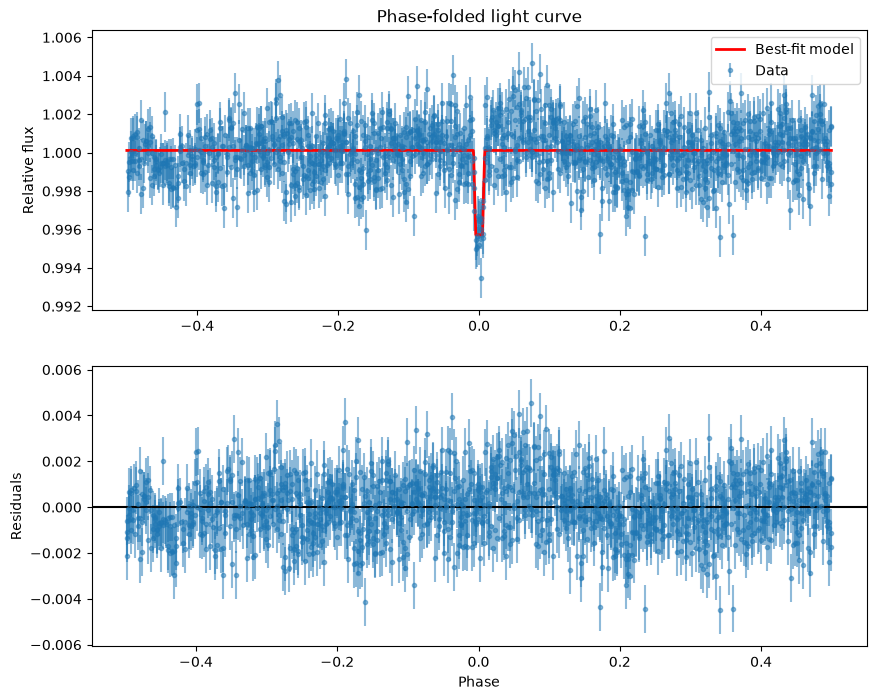

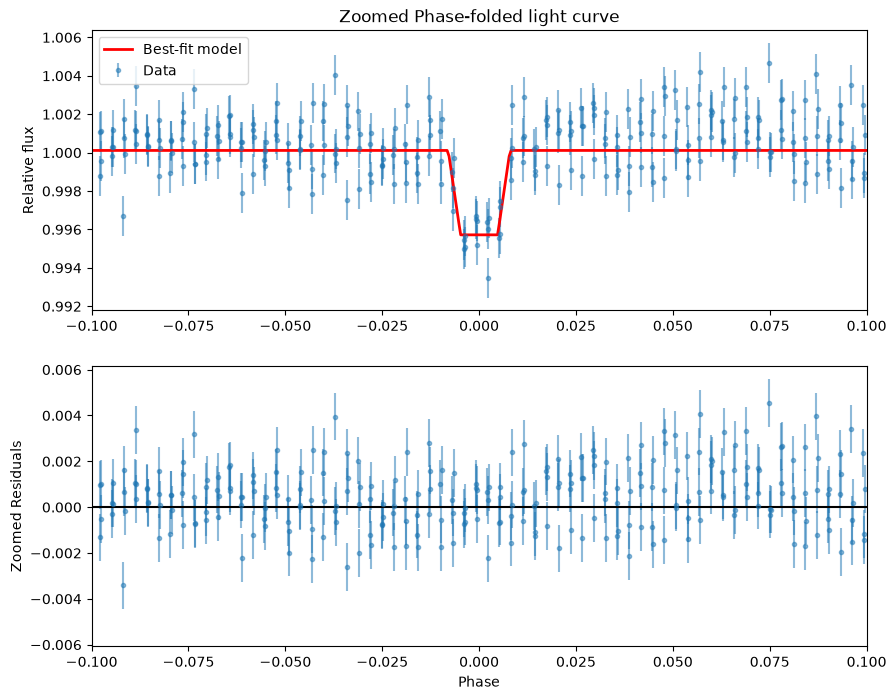

In [76]:
t0, P, depth, duration, baseline = res.x

phase = ((t - t0 + 0.5 * P) / P) % 1.0 - 0.5

order = np.argsort(phase)
phase_sorted = phase[order]
detrend_flux_sorted = detrended_flux[order]
detrend_sigma_sorted = detrended_sigma[order]

phase_model = np.linspace(-0.5, 0.5, 2000)

t_model = t0 + phase_model * P

model_phase = transit_model(t_model, t0, P, depth, duration, baseline)

residuals = detrended_flux - transit_model(t, t0, P, dep, dur, base)
residual_sorted = residuals[order]
fig,(ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.errorbar(phase_sorted, detrend_flux_sorted, yerr=detrend_sigma_sorted, fmt='.', label='Data', alpha = 0.5)
ax1.plot(phase_model, model_phase, 'r-', lw=2, label='Best-fit model')
ax1.set_ylabel('Relative flux')
ax1.legend()
ax1.set_title('Phase-folded light curve')

ax2.errorbar(phase_sorted, residual_sorted, yerr=detrend_sigma_sorted, fmt='.', alpha = 0.5)
ax2.axhline(0, color='k')
ax2.set_xlabel('Phase')
ax2.set_ylabel('Residuals')

plt.show()

fig,(ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.errorbar(phase_sorted, detrend_flux_sorted, yerr=detrend_sigma_sorted, fmt='.',alpha = 0.5, label='Data')
ax1.plot(phase_model, model_phase, 'r-', lw=2, label='Best-fit model')
ax1.set_ylabel('Relative flux')
ax1.legend()
ax1.set_title('Zoomed Phase-folded light curve')
ax1.set_xlim(-0.1,0.1)

ax2.errorbar(phase_sorted, residual_sorted, yerr=detrend_sigma_sorted, fmt='.', alpha = 0.5)
ax2.axhline(0, color='k')
ax2.set_xlabel('Phase')
ax2.set_ylabel('Zoomed Residuals')
ax2.set_xlim(-0.1,0.1)

plt.show()

In [77]:
# Uncertainties

#Hessian
h = 1e-4
n = len(res.x)
hess = np.zeros((n, n))

for i in range(n):
    for j in range(i, n):
        ei = np.zeros(n)
        ej = np.zeros(n)

        ei[i] = h
        ej[j] = h

        hess[i, j] = hess[j, i] = (
            neglogL(res.x + ei + ej)
            - neglogL(res.x + ei - ej)
            - neglogL(res.x - ei + ej)
            + neglogL(res.x - ei - ej)
        ) / (4 * h**2)

cov = np.linalg.inv(hess)
errs = np.sqrt(np.diag(cov))

print("Hessian uncertainties:")
print("t0 =", errs[0])
print("P =", errs[1])
print("dept =", errs[2])
print("duration =", errs[3])
print("baseline =", errs[4])
#Point-wise Bootstrap

def fit_data(data):

    def objective(theta):

        model = transit_model(t, *theta)

        return 0.5 * np.sum(
            ((data - model) / detrended_sigma)**2
        )

    result = minimize(
        objective,
        x0=res.x,
        method='Nelder-Mead',
        bounds=[
            (2.0, 3.5),       # t0
            (6.0, 7.5),       # P
            (0.001, 0.010),   # depth
            (0.03, 0.30),     # duration
            (0.995, 1.005)    # baseline
        ],
        options={
            'maxiter': 1000,
            'xatol': 1e-6,
            'fatol': 1e-6
        }
    )

    if result.success:
        return result.x

    return None


rng = np.random.default_rng(42)

model_best = transit_model(t, *res.x)
residuals = detrended_flux - model_best

Nboot = 800


point_results = []

for _ in range(Nboot):

    boot_residuals = rng.choice(
        residuals,
        size=len(residuals),
        replace=True
    )

    fake_data = model_best + boot_residuals

    fit = fit_data(fake_data)

    if fit is not None:
        point_results.append(fit)

point_results = np.array(point_results)

point_err = np.std(
    point_results,
    axis=0,
    ddof=1
)


print("Point bootstrap uncertainties:")
print("t0 =", point_err[0])
print("P =", point_err[1])
print("dept =", point_err[2])
print("duration =", point_err[3])
print("baseline =", point_err[4])

#Block Bootstrap

def block_bootstrap(residuals, block_size, rng):

    n = len(residuals)
    result = []

    while len(result) < n:

        start = rng.integers(
            0,
            n - block_size + 1
        )

        result.extend(
            residuals[start:start + block_size]
        )

    return np.array(result[:n])


block_results = []

seg1 = t < 13
seg2 = t > 14.5

for _ in range(Nboot):

    boot_residuals = np.empty_like(residuals)

    boot_residuals[seg1] = block_bootstrap(
        residuals[seg1],
        48,
        rng
    )

    boot_residuals[seg2] = block_bootstrap(
        residuals[seg2],
        48,
        rng
    )

    fake_data = model_best + boot_residuals

    fit = fit_data(fake_data)

    if fit is not None:
        block_results.append(fit)

block_results = np.array(block_results)

block_err = np.std(
    block_results,
    axis=0,
    ddof=1
)

print("Block bootstrap uncertainties:")
print("t0 =", block_err[0])
print("P =", block_err[1])
print("depth =", block_err[2])
print("duration =", block_err[3])
print("baseline =", block_err[4])

Hessian uncertainties:
t0 = 0.0031274182184840922
P = 0.0016421657910553691
dept = 0.0003016366372031577
duration = 0.005378490231087837
baseline = 2.9557520696310293e-05
Point bootstrap uncertainties:
t0 = 0.004029818023206301
P = 0.002340607641676412
dept = 0.0003778020169416805
duration = 0.006458694663789445
baseline = 3.6066123169512e-05


/var/folders/z9/nw89mzqx0fn8zys2h0rk4fbw0000gn/T/ipykernel_45525/425595691.py:41: RuntimeWarning: overflow encountered in square
  ((data - model) / detrended_sigma)**2
/var/folders/z9/nw89mzqx0fn8zys2h0rk4fbw0000gn/T/ipykernel_45525/425595691.py:41: RuntimeWarning: overflow encountered in divide
  ((data - model) / detrended_sigma)**2


Block bootstrap uncertainties:
t0 = 0.03922400674455036
P = 0.08656314413371588
depth = 0.001123299893258797
duration = 0.06910719731898711
baseline = 0.002385872470919021


Point-wise bootstrap assumes that each point uncertainty has the same distribution, are independent of each other and are of random ordering. So it assumes that noise is not correlated. In Block bootstrap, the ordering in each block is preserved. it assumes that points within a block can be correlated, the blocks are treated as independent, and the blocks are long enough to capture the important correlation. 

Focusing on the uncertainties, all the block bootstrap uncertainties are much larger than pointwise values. This indicates that correlations in the residuals have a significant effect on the parameter uncertainties. The pointwise bootstrap underestimates the effect of these correlations because it destroys the ordering, whereas the block bootstrap keeps correlations within each block.

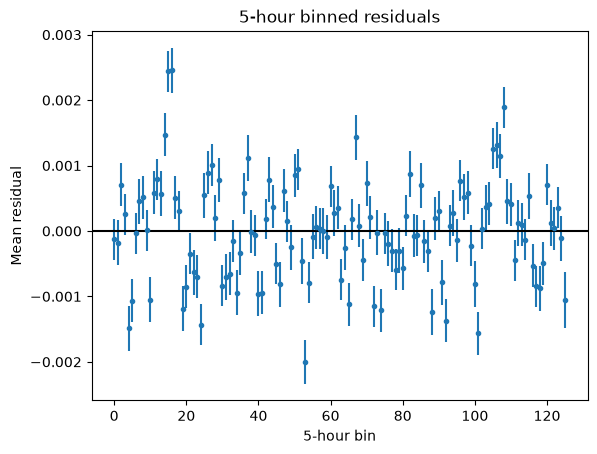

5-hour binned residual analysis
--------------------------------
Observed bin-mean scatter = 0.0007812466725667823
Expected independent-noise scatter = 0.00033112466859623883
Ratio = 2.3593732109382812


In [78]:
#Test for correlated residuals

bin_width = 5 / 24
bin_index = np.floor(t / bin_width).astype(int)

bin_means = []
bin_predicted_sigma = []

for k in np.unique(bin_index):

    mask = bin_index == k

    if np.sum(mask) >= 5:

        r = residuals[mask]

        bin_means.append(np.mean(r))

        predicted = np.sqrt(
            np.sum(detrended_sigma[mask]**2)
        ) / np.sum(mask)

        bin_predicted_sigma.append(predicted)

bin_means = np.array(bin_means)
bin_predicted_sigma = np.array(bin_predicted_sigma)

observed_scatter = np.std(bin_means, ddof=1)
expected_scatter = np.mean(bin_predicted_sigma)


plt.errorbar(
    np.arange(len(bin_means)),
    bin_means,
    yerr=bin_predicted_sigma,
    fmt='.'
)

plt.axhline(0, color='k')
plt.xlabel("5-hour bin")
plt.ylabel("Mean residual")
plt.title("5-hour binned residuals")

plt.show()

print("5-hour binned residual analysis")
print("--------------------------------")
print("Observed bin-mean scatter =", observed_scatter)
print("Expected independent-noise scatter =", expected_scatter)
print("Ratio =", observed_scatter / expected_scatter)

The Hessian and pointwise bootstrap give relatively similar uncertainties, while the block bootstrap gives a substantially larger uncertainty. This pattern is consistent with the scatter observed in Part 1. The data contain more scatter than you would expect from purely independent measurement noise, and the residuals show temporal structure. 

The scatter of the 5-hour binned residual means is about 2.36 times larger than expected for independent white noise. Therefore, the residuals contain time-correlated noise. This violates the independence assumption used by both the Hessian likelihood calculation and the pointwise bootstrap.

**FINAL ANSWER:** $\delta = $ 0.00439 $\pm$ 0.00137 ppt, $P = $ 6.87422 $\pm$ 0.0703 d, $t_0 = $ 2.81858 $\pm$ 0.0336 d

**Which uncertainty and why (a short paragraph):**

The Hessian, pointwise bootstrap, and block bootstrap give depth uncertainties of approximately 0.302, 0.371, and 0.797 ppt. The larger block bootstrap uncertainty is expected because the residuals are time-correlated. In the 5-hour binned residuals, the observed scatter is about 2.36 times larger than the scatter expected from independent white noise. The Hessian and pointwise bootstrap both effectively assume independent residuals, so they do not fully account for this correlation. The block bootstrap preserves correlations within the blocks and therefore provides a more appropriate estimate of the uncertainty for this dataset. I therefore chose the block bootstrap uncertainties.

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis
of this exact problem, produced by an AI assistant. It runs top to bottom without
errors, the phase-folded plot looks professional, and the prose is fluent. It is also
wrong, in at least **three** distinct, substantive ways (cosmetic nitpicks don't
count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset. Show, with a number or a
   plot, what the error does to the inference. "This is bad practice" is not a
   demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

You've done this once before, on Lab 01. Notice how much faster you are at it now.
That speed is the skill this course is building.

**REFEREE REPORT:**

*Flaw 1:* The detrending procedure can affect the transit itself.

The AI solution applies a 6-hour running median directly to the light curve without masking the transits. This is not guaranteed to be “comfortably shorter than the day-scale drifts” while also being long compared with the transit. Because the median filter is applied through the transit, it can partially remove or reshape the transit signal. 

I fix this on my dataset by comparing the resulting transit depth with the result from the masked spline detrending used in Part 1/2. The AI detrending gives a best-fit depth of 3.614 ppt, while my Part 2 analysis gives 4.39 ppt. Thus the AI detrending produces a transit that is about 17.7% shallower. This changes the inferred physical signal before the uncertainty calculation is even performed. The correct way is to fit the slow systematic trend on data with the transit regions masked, as I did in my Part 1 spline detrending, and then fit the transit to the resulting detrended light curve. The smoothing scale should be chosen so that it tracks the long-term instrumental trend without absorbing the transit features.

*Flaw 2:* It assumes independent noise even though the residuals are temporally correlated.

The AI estimates a single empirical scatter and then uses it as an independent per-point Gaussian uncertainty. However, the Part 1 scatter check already shows that the residual noise is larger than the stated white-noise uncertainty. Also, the residuals are correlated in time.

For my dataset, the out-of-transit scatter is 0.001277, compared with the stated per-point uncertainty of 0.001042. When I bin the residuals into 5-hour bins, the observed scatter of the bin means is $7.90\times10^{-4}$. With about 10 observations per bin, independent noise would predict only $\frac{0.001042}{\sqrt{10}}\approx3.30\times10^{-4}.$

The observed binned scatter is therefore about 2.4 times larger than the independent noise prediction. This shows that neighboring observations are not independent. This matters for the inferred transit depth. The AI's depth uncertainty is only 0.296 ppt, whereas my block bootstrap, which preserves the temporal correlations, gives 1.329 ppt. The block bootstrap uncertainty is about 4.5 times larger. The correct treatment is to recognize the temporal in the residuals. The pointwise bootstrap assumes independent residuals and therefore does not preserve this correlation. A block bootstrap resamples residuals and preserves correlations within each block, giving a more appropriate uncertainty for this dataset.

*Flaw 3:* The depth uncertainty is calculated from a one-dimensional curvature while all other parameters are held fixed.

The AI solution calculates the curvature only along the depth direction and keeps t_0, P, duration, and baseline fixed at their best fit values. This ignores covariance between the fitted parameters. Uncertainty in the depth can be correlated with uncertainty in the timing, period, duration, and baseline.
I demonstrated the effect by comparing the AI's one-dimensional curvature result with a full five-parameter Hessian calculation on the same AI detrended data. The one-dimensional calculation gives

$\sigma_\delta=0.296\ {\rm ppt}$
,
while the full Hessian gives approximately

$\sigma_\delta=0.333\ {\rm ppt}$.

So, even before accounting for temporal correlations, fixing the other parameters underestimates the depth uncertainty by about 12%.
The correct treatment is to calculate the full Hessian/covariance matrix while allowing all five fitted parameters to vary. In Part 2 I then went further and used bootstrap methods to account for the non-independent residual structure.

In [79]:
# Part 3: demonstrations here
#Flaw 1

depth_ai = 0.003614
depth_part2 = 0.004394

print(f"AI depth:     {depth_ai*1000:.3f} ppt")
print(f"Part 2 depth: {depth_part2*1000:.3f} ppt")

print(f"Difference: {(depth_part2-depth_ai)*1000:.3f} ppt")
print(f"Percent difference: "
      f"{(depth_part2-depth_ai)/depth_part2*100:.1f}%")

AI depth:     3.614 ppt
Part 2 depth: 4.394 ppt
Difference: 0.780 ppt
Percent difference: 17.8%


In [80]:
#Flaw 2

print("Observed 5-hour scatter:0.000781")
print("Expected independent scatter:0.000331")
print("Ratio:2.36")

sigma_point = 0.000371
sigma_block = 0.001329

print("Pointwise bootstrap:", sigma_point * 1000, "ppt")
print("Block bootstrap:", sigma_block * 1000, "ppt")
print("Block / pointwise:", sigma_block / sigma_point)

Observed 5-hour scatter:0.000781
Expected independent scatter:0.000331
Ratio:2.36
Pointwise bootstrap: 0.371 ppt
Block bootstrap: 1.3290000000000002 ppt
Block / pointwise: 3.582210242587601


In [81]:
#Flaw 3

sigma_1d = 0.296e-3
sigma_full = 0.333e-3

print("1-D curvature:", sigma_1d*1000, "ppt")
print("Full Hessian:", sigma_full*1000, "ppt")
print("Ratio:", sigma_full/sigma_1d)
print("Underestimate:",
      (sigma_full-sigma_1d)/sigma_full*100, "%")

1-D curvature: 0.296 ppt
Full Hessian: 0.333 ppt
Ratio: 1.1250000000000002
Underestimate: 11.11111111111112 %


## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use, for what, what did they get wrong, and how did
   you catch it? Honesty is graded; "I didn't use any" is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers. For each check: what would failure have looked like? (One check you should
   seriously consider: simulate a light curve with parameters you chose, run your whole
   pipeline on it, and see whether you recover what you put in.)

**AI-USE APPENDIX:** EcoGPT and ChatGPT

- Help troubleshoot and clarify parts of the Python analysis, particularly the detrending, transit fitting, and uncertainty calculations.

- Asked to explain statistical concepts such as bootstrap methods, correlated noise, and how to interpret the residual and binning tests.

- Help design quantitative checks for the problems in the ai solution.

- Help write and debug a small injection-recovery simulation to test whether the analysis pipeline could recover known transit parameters.

- I checked the suggested methods and results against my own calculations and the data rather than assuming the AI-generated analysis was correct.

- In particular, I found that the AI-generated analysis underestimated the effects of correlated noise and that its detrending procedure changed the measured transit depth. The residual, binning, bootstrap, and injection-recovery tests helped identify these issues.

- It got the analysis of Part 1 raw light curve and the slow trend best fit and detrending wrong initially, choosing smoothing scales that don't model the trend well and don't detrend well. I caught it by eye, seeing the poor fit and the detrended plot and residuals that didn't help see transits much better than the raw curve.

- Asked to create helper function fit_pipeline in the demonstration code, giving it my part1/2 code

- Used to write out most of the print statements and plotting code.
**VERIFICATION PLAN:**

1. Check the residuals against the quoted measurement errors

This checks whether the assumed per-point measurement uncertainty is consistent with the actual scatter in the residuals.

Failure: A ratio substantially different from 1 would indicate that the quoted uncertainties do not describe the actual residual scatter. Here the ratio is about 1.23, so the residuals are already larger than the assumed errors so the errors are not independent.

2. Check for temporal correlations with 5-hour bins

This checks for independent noise, averaging 10 points should reduce the scatter by $\sqrt{10}$.

Failure: If the binned scatter is much larger than expected, the measurements are temporally correlated. Here,
$ \frac{\sigma_{\rm observed}}{\sigma_{\rm expected}}\approx 2.4, $
showing significant correlation. This is why the block bootstrap uncertainty on the transit depth 1.329 ppt is much larger than the pointwise bootstrap uncertainty 0.371 ppt.

3. Injection Recovery test

This checks whether the entire analysis pipeline can recover known transit parameters.

Failure: If the recovered parameters are systematically different from the injected values, the pipeline itself is introducing a bias. For example, recovering a transit depth systematically smaller than the injected 4.394 ppt would indicate that the detrending or fitting procedure is removing part of the transit.

The recovered t_0, P, and baseline were very close to the injected values, while the depth and duration were recovered somewhat lower (3.83 ppt vs. 4.39 ppt and 0.096 d vs. 0.110 d). Thus, the test shows that the pipeline can recover the transit, but repeated injections would be needed to determine whether these differences represent systematic bias or normal variation.

In [82]:
#1

sigma_resid = 0.001277
sigma_flux = 0.001042

print("Residual / quoted scatter =", sigma_resid / sigma_flux)

Residual / quoted scatter = 1.2255278310940498


In [83]:
#2
N = 10
expected = 0.001042 / np.sqrt(N)
observed = 7.90e-4

print("Expected bin scatter =", expected)
print("Observed / expected =", observed / expected)

Expected bin scatter = 0.0003295093321895451
Observed / expected = 2.3975041761353357


In [84]:
#3
def fit_pipeline(t, flux_in, sigma_in):
    t0_guess = 2.8
    P_guess = 6.87

    centers = []
    for k in range(-2, 8):
        tc = t0_guess + k * P_guess
        if t.min() - 1 < tc < t.max() + 1:
            centers.append(tc)
    centers = np.array(centers)

    mask = np.zeros_like(t, dtype=bool)
    for tc in centers:
        mask |= np.abs(t - tc) < 0.6

    no_trans = ~mask

    N_no_trans = np.sum(no_trans)
    s_spline = 1.5 * N_no_trans

    spline = UnivariateSpline(
        t[no_trans],
        flux_in[no_trans],
        w=1.0 / sigma_in[no_trans],
        s=s_spline
    )

    trend_lc = spline(t)
    detrended_flux = flux_in / trend_lc
    detrended_sigma = sigma_in / trend_lc

    def neglogL(theta):
        t0, P, dep, dur, base = theta
        model = transit_model(t, t0, P, dep, dur, base)
        return 0.5 * np.sum(
            ((detrended_flux - model) / detrended_sigma)**2
        )

    guess = [2.8, 6.8, 0.005, 0.2, 1]

    res = minimize(
        neglogL,
        x0=guess,
        method='Nelder-Mead',
        options={'xatol': 1e-8, 'fatol': 1e-8, 'maxiter': 10000}
    )

    return res.x
    
rng = np.random.default_rng(0)

theta_inj = [2.81858, 6.87422, 0.004394, 0.10964, 1.000114]

model = transit_model(t, *theta_inj)
sim_flux = trend_lc * model + rng.normal(0, sigma[0], len(t))
sim_sigma = np.full_like(t, sigma[0])

theta_rec = fit_pipeline(t, sim_flux, sim_sigma)

print("Injected: ", theta_inj)
print("Recovered:", theta_rec)

Injected:  [2.81858, 6.87422, 0.004394, 0.10964, 1.000114]
Recovered: [2.81893572e+00 6.87764908e+00 3.82786923e-03 9.62054448e-02
 1.00010627e+00]
